# Diabetes Risk Prediction — End-to-End ML Pipeline

**Dataset:** Pima Indians Diabetes Database (UCI / Kaggle)  
**Goal:** Predict whether a patient is diabetic based on clinical diagnostic measurements.  
**Approach:** Full pipeline — EDA → preprocessing → model comparison (Logistic Regression, Random Forest, XGBoost) → SHAP explainability.

---

## 1. Setup & Dependencies

In [39]:
!pip install xgboost shap --quiet

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Load the Dataset

The Pima Indians Diabetes Database contains 768 female patients of Pima Indian heritage, aged 21+. Each row represents one patient with 8 clinical features and a binary outcome (diabetic or not).

| Feature | Description |
|---|---|
| Pregnancies | Number of pregnancies |
| Glucose | Plasma glucose concentration (2hr oral glucose tolerance test) |
| BloodPressure | Diastolic blood pressure (mm Hg) |
| SkinThickness | Triceps skin fold thickness (mm) |
| Insulin | 2-hour serum insulin (mu U/ml) |
| BMI | Body mass index |
| DiabetesPedigreeFunction | Likelihood of diabetes based on family history |
| Age | Age in years |
| Outcome | 1 = Diabetic, 0 = Not diabetic |

In [41]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df = pd.read_csv(url, header=None, names=columns)
print(f'Dataset shape: {df.shape}')
df.head(5)

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3. Exploratory Data Analysis (EDA)

Before building any model, we need to understand the data — its distributions, class balance, missing values, and feature relationships.

In [42]:
# Basic statistics
print('Dataset Info')
print(df.info())
print('\nDescriptive Statistics')
df.describe().round(2)

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Descriptive Statistics


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


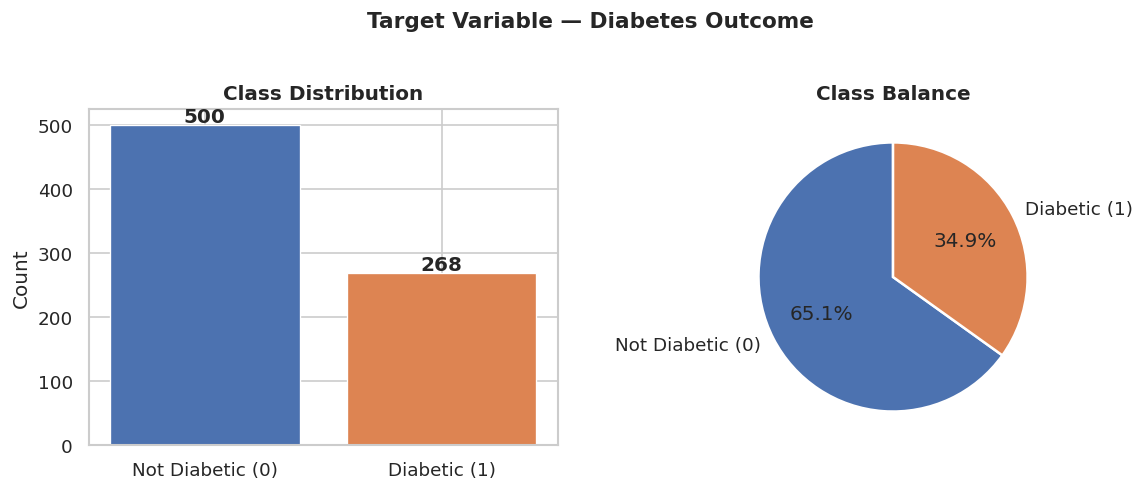


Class balance: 500 non-diabetic (65.1%) | 268 diabetic (34.9%)


In [43]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['Outcome'].value_counts()
labels = ['Not Diabetic (0)', 'Diabetic (1)']
colors = ['#4C72B0', '#DD8452']

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Balance', fontweight='bold')

plt.suptitle('Target Variable — Diabetes Outcome', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

print(f'\nClass balance: {counts[0]} non-diabetic ({counts[0]/len(df)*100:.1f}%) | {counts[1]} diabetic ({counts[1]/len(df)*100:.1f}%)')

In [44]:
# Identify biologically impossible zero values
# Glucose, BloodPressure, SkinThickness, Insulin, BMI cannot be 0
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
zero_counts = (df[zero_cols] == 0).sum()

print('Zero values in clinical features (biologically impossible — treated as missing):')
print(zero_counts[zero_counts > 0].to_string())
print(f'\nTotal potentially missing values: {zero_counts.sum()}')

Zero values in clinical features (biologically impossible — treated as missing):
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11

Total potentially missing values: 652


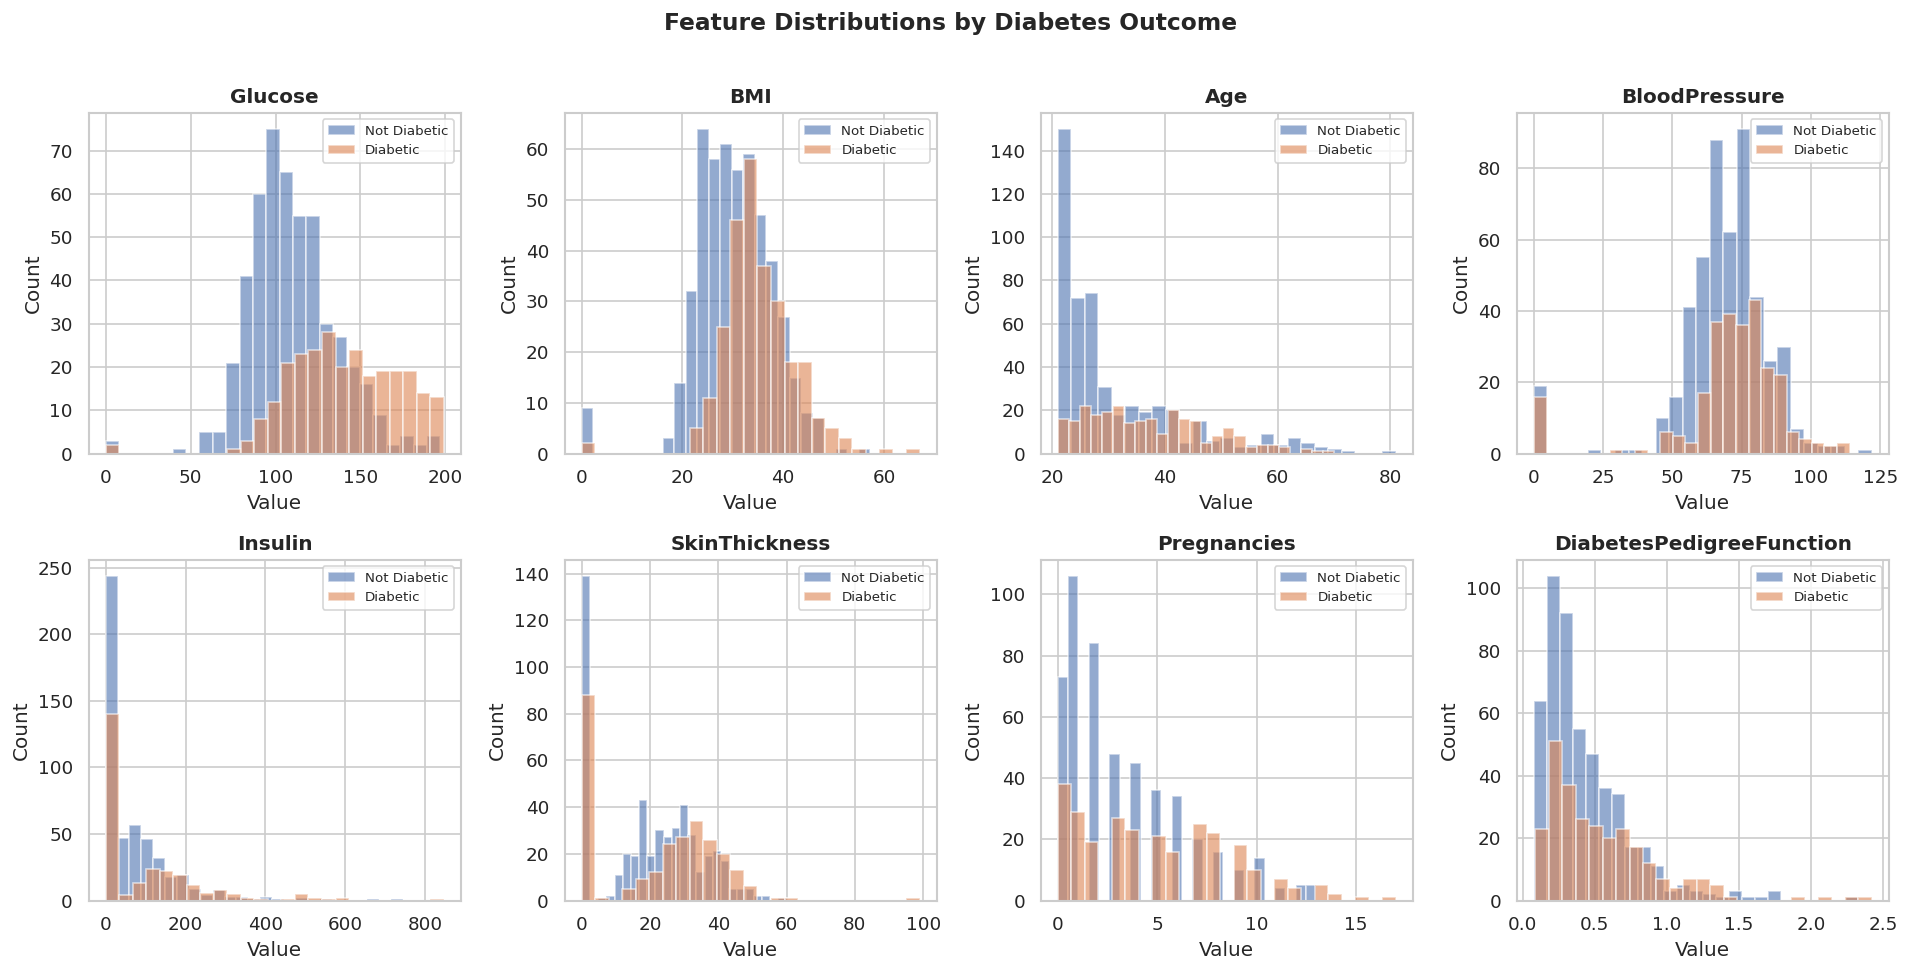

In [45]:
# Feature distributions by outcome
features = ['Glucose', 'BMI', 'Age', 'BloodPressure',
            'Insulin', 'SkinThickness', 'Pregnancies', 'DiabetesPedigreeFunction']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    for outcome, color, label in [(0, '#4C72B0', 'Not Diabetic'), (1, '#DD8452', 'Diabetic')]:
        subset = df[df['Outcome'] == outcome][feat]
        axes[i].hist(subset, bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Diabetes Outcome', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight')
plt.show()

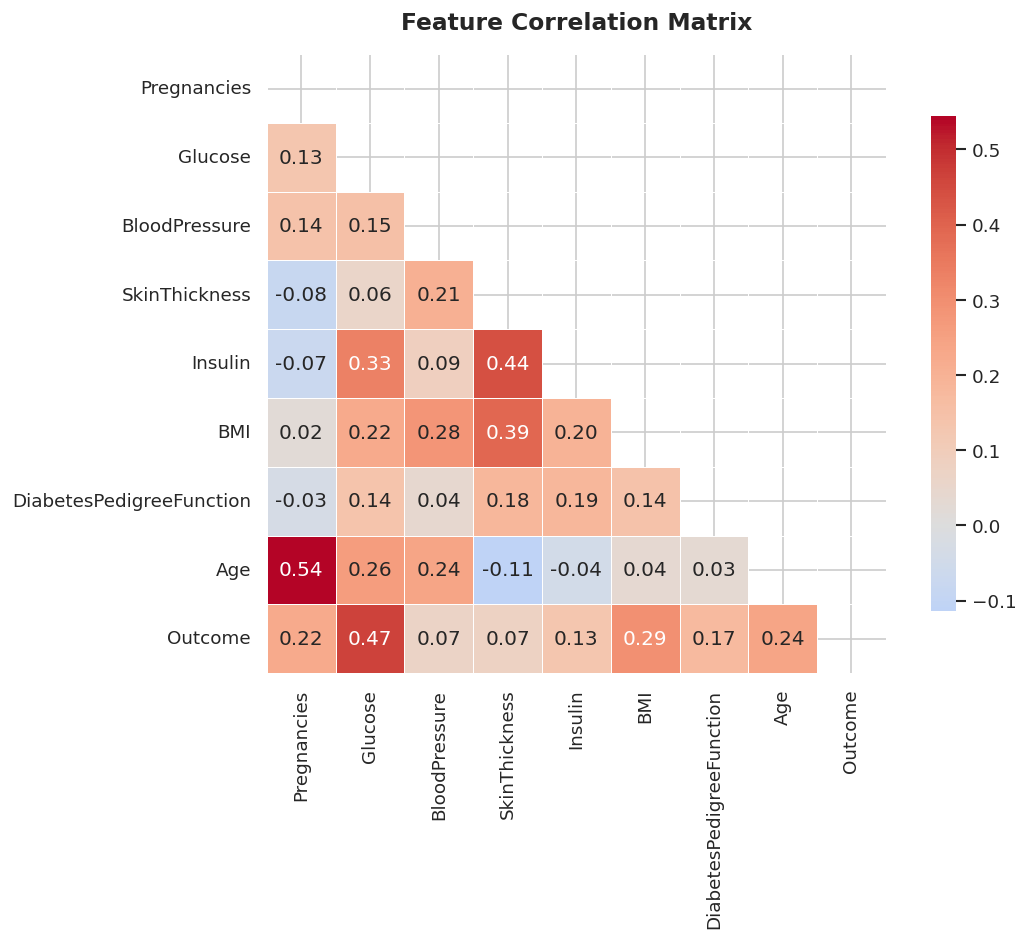

Top correlations with Outcome:
Glucose                     0.467
BMI                         0.293
Age                         0.238
Pregnancies                 0.222
DiabetesPedigreeFunction    0.174
Insulin                     0.131
SkinThickness               0.075
BloodPressure               0.065


In [46]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('Top correlations with Outcome:')
print(corr['Outcome'].drop('Outcome').sort_values(ascending=False).round(3).to_string())

## 4. Preprocessing

Three key steps:
1. **Replace biologically impossible zeros** with the median value (median is robust to outliers)
2. **Split** into training (80%) and test (20%) sets using stratified sampling to preserve class balance
3. **Scale** features using StandardScaler (required for Logistic Regression;)

In [47]:
# Step 1: Replace impossible zeros with median
df_clean = df.copy()
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in zero_cols:
    median_val = df_clean[col].replace(0, np.nan).median()
    df_clean[col] = df_clean[col].replace(0, median_val)

print('Zero values replaced with median. Verification:')
print((df_clean[zero_cols] == 0).sum())

# Step 2: Feature / target split
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

# Step 3: Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 4: Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\nTraining set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'Features:     {X_train.shape[1]}')

Zero values replaced with median. Verification:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Training set: 614 samples
Test set:     154 samples
Features:     8


## 5. Model Training & Evaluation

We train and compare three models:
- **Logistic Regression** — linear baseline, highly interpretable
- **Random Forest** — ensemble of decision trees, handles non-linearity well
- **XGBoost** — gradient boosting, typically the strongest out-of-box performer on tabular data

Each model is evaluated using 5-fold cross-validation on training data, then tested on the held-out test set.

In [48]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                         use_label_encoder=False, eval_metric='logloss',
                                         random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    # Use scaled data for LR, unscaled for tree-based
    X_tr = X_train_scaled if name == 'Logistic Regression' else X_train
    X_te = X_test_scaled  if name == 'Logistic Regression' else X_test

    # Cross-validation
    cv_scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring='roc_auc')

    # Fit and evaluate on test set
    model.fit(X_tr, y_train)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    results[name] = {
        'model':    model,
        'X_te':     X_te,
        'y_pred':   y_pred,
        'y_proba':  y_proba,
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc':  roc_auc_score(y_test, y_proba),
        'cv_auc':   cv_scores.mean(),
        'cv_std':   cv_scores.std()
    }

    print(f'{name}')
    print(f'  CV AUC (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'  Test Accuracy:   {accuracy_score(y_test, y_pred):.4f}')
    print(f'  Test ROC-AUC:    {roc_auc_score(y_test, y_proba):.4f}')
    print()

Logistic Regression
  CV AUC (5-fold): 0.8428 ± 0.0190
  Test Accuracy:   0.7078
  Test ROC-AUC:    0.8130

Random Forest
  CV AUC (5-fold): 0.8361 ± 0.0194
  Test Accuracy:   0.7273
  Test ROC-AUC:    0.8113

XGBoost
  CV AUC (5-fold): 0.8114 ± 0.0157
  Test Accuracy:   0.7662
  Test ROC-AUC:    0.8220



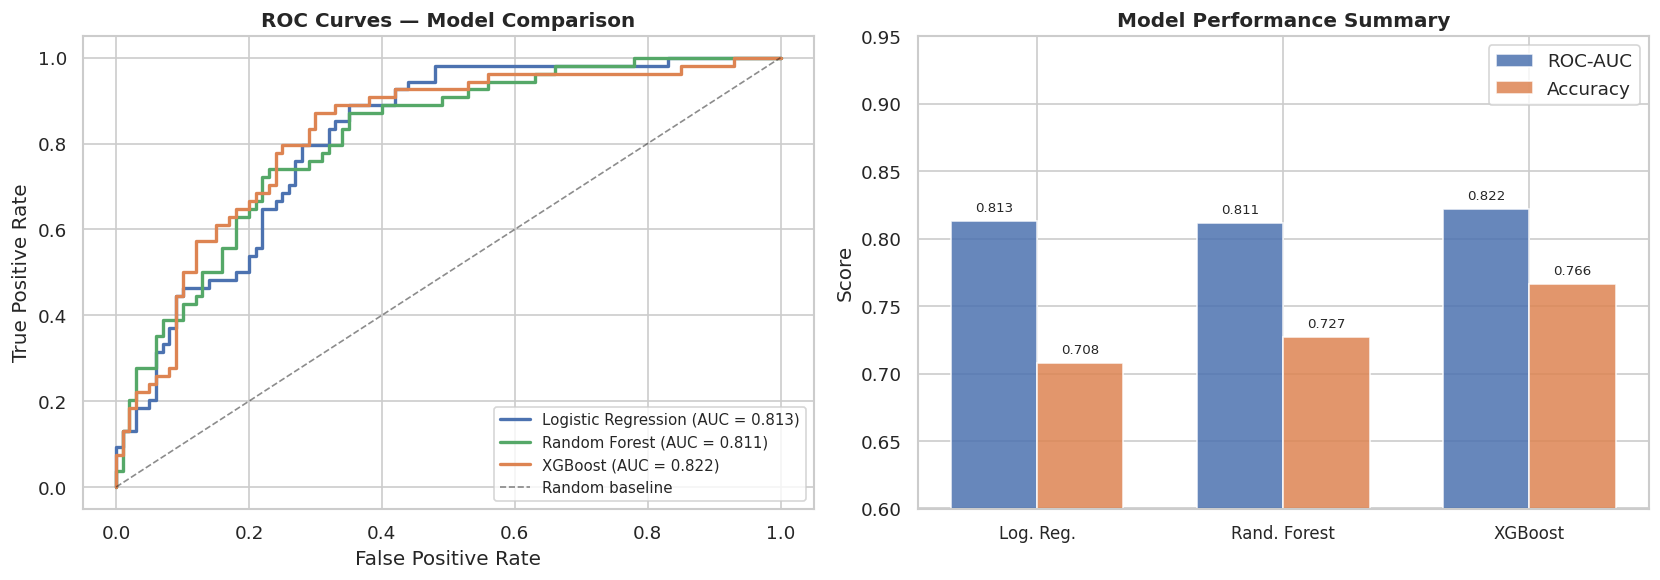

In [49]:
# ROC Curves — all models on one plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4C72B0', '#55A868', '#DD8452']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {res['roc_auc']:.3f})", color=color, lw=2)

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random baseline')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — Model Comparison', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)

# Model comparison bar chart
model_names = list(results.keys())
aucs = [results[m]['roc_auc'] for m in model_names]
accs = [results[m]['accuracy'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35
axes[1].bar(x - width/2, aucs, width, label='ROC-AUC', color='#4C72B0', alpha=0.85)
axes[1].bar(x + width/2, accs, width, label='Accuracy', color='#DD8452', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Log. Reg.', 'Rand. Forest', 'XGBoost'], fontsize=10)
axes[1].set_ylim(0.6, 0.95)
axes[1].set_ylabel('Score')
axes[1].set_title('Model Performance Summary', fontweight='bold')
axes[1].legend()
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

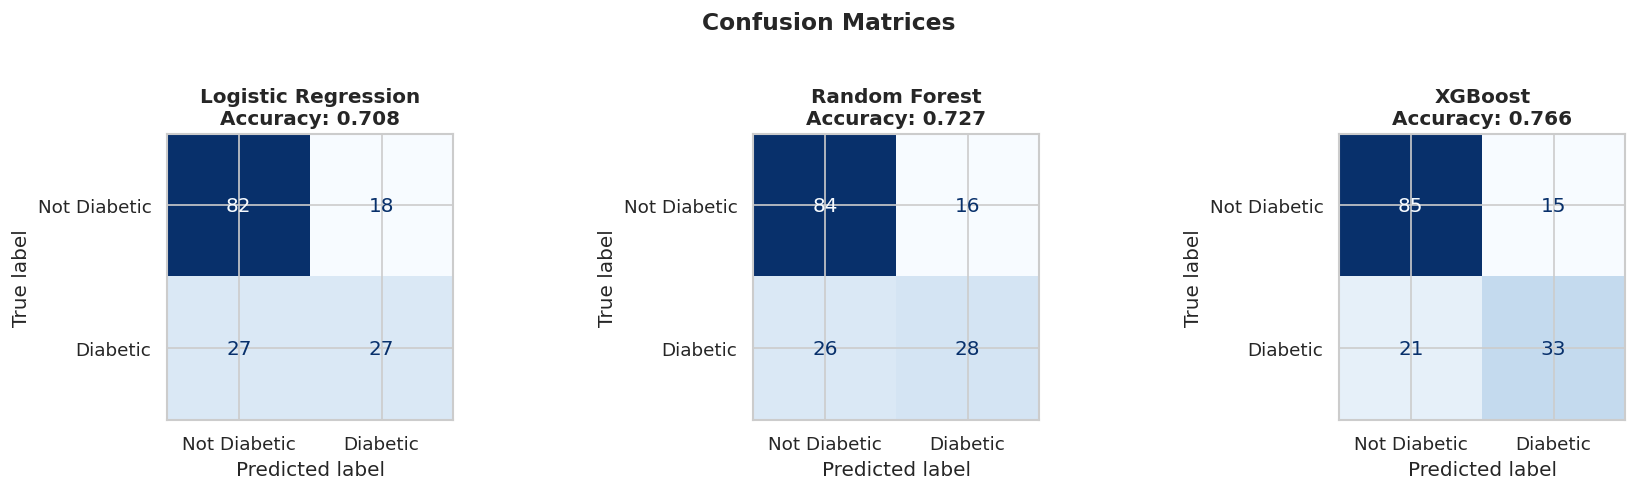

In [50]:
# Confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Diabetic', 'Diabetic'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAccuracy: {res["accuracy"]:.3f}', fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

In [51]:
# Detailed classification report for best model (XGBoost)
best_model_name = max(results, key=lambda m: results[m]['roc_auc'])
print(f'Best model by ROC-AUC: {best_model_name}\n')
print(classification_report(y_test, results[best_model_name]['y_pred'],
                             target_names=['Not Diabetic', 'Diabetic']))

Best model by ROC-AUC: XGBoost

              precision    recall  f1-score   support

Not Diabetic       0.80      0.85      0.83       100
    Diabetic       0.69      0.61      0.65        54

    accuracy                           0.77       154
   macro avg       0.74      0.73      0.74       154
weighted avg       0.76      0.77      0.76       154



## 6. Feature Importance & SHAP Explainability

SHAP (SHapley Additive exPlanations) is a method from game theory that explains **how much each feature contributed to each individual prediction**. Unlike simple feature importance scores, SHAP shows both the magnitude and direction of each feature's effect.

This is critical in healthcare ML — a model that can't be explained can't be trusted clinically.

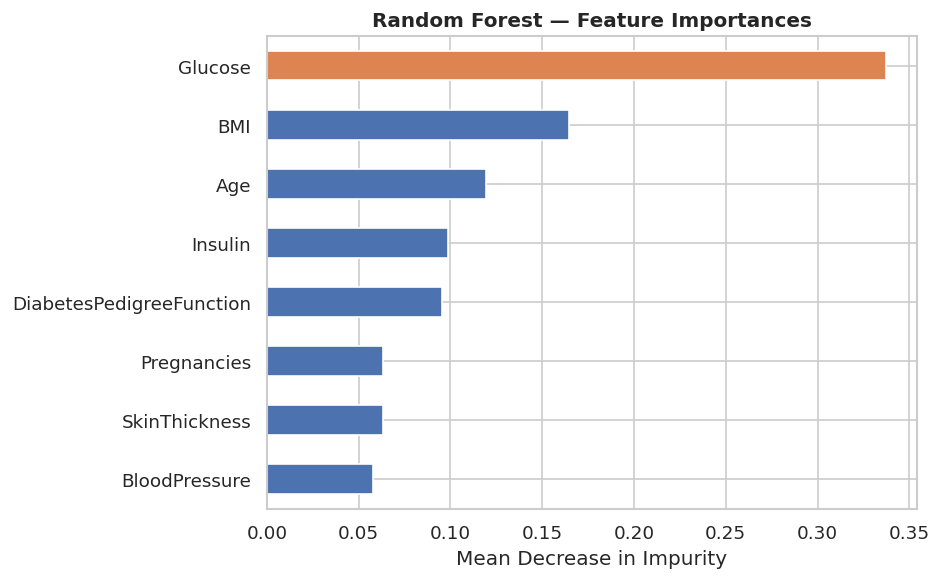

In [52]:
# Random Forest feature importance (built-in)
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors_bar = ['#4C72B0' if v < importances.max() else '#DD8452' for v in importances.values]
importances.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='white')
ax.set_title('Random Forest — Feature Importances', fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

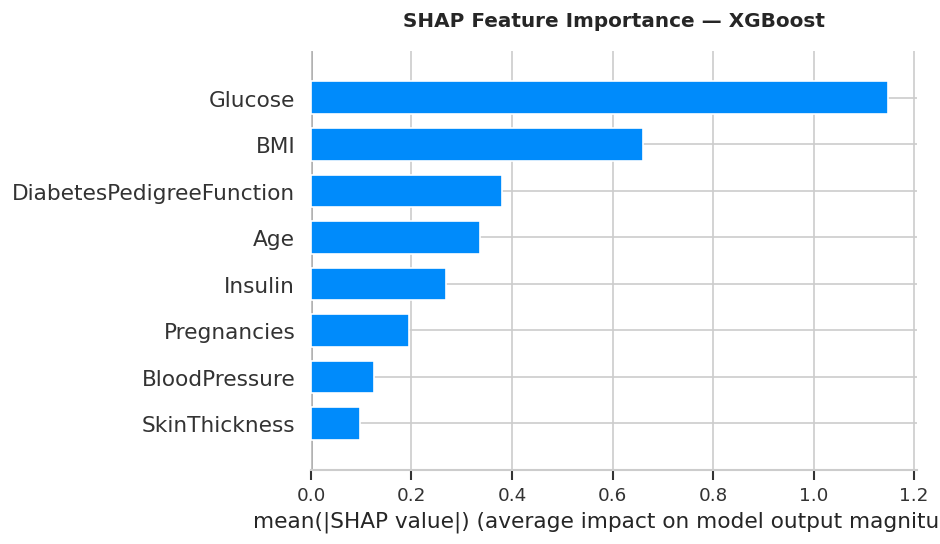

In [53]:
# SHAP explainability on XGBoost (best model)
xgb_model = results['XGBoost']['model']

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Summary plot — shows feature impact across all predictions
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — XGBoost', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_bar.png', bbox_inches='tight')
plt.show()

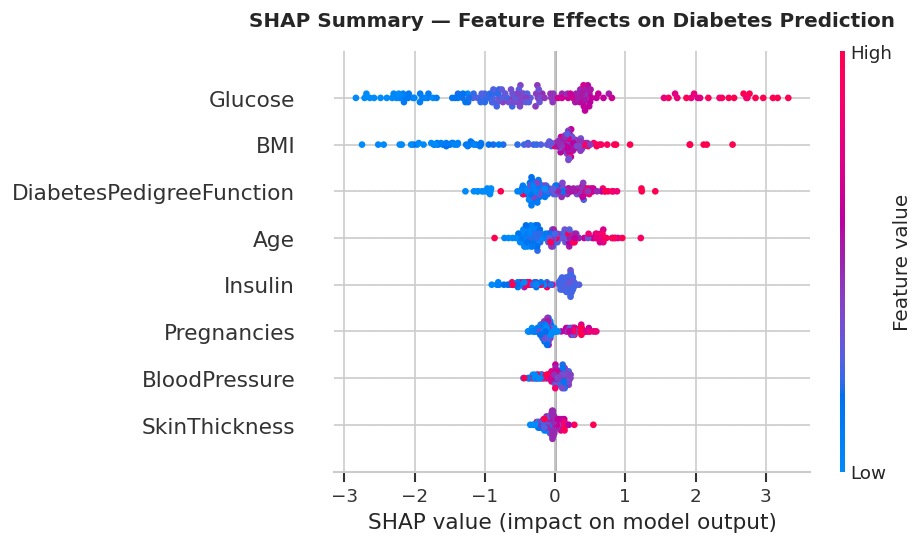

Interpretation: Red = high feature value, Blue = low feature value.
Positive SHAP value = pushes prediction toward diabetic (1).
Negative SHAP value = pushes prediction toward non-diabetic (0).


In [54]:
# SHAP beeswarm plot — shows direction of each feature's effect
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist(), show=False)
plt.title('SHAP Summary — Feature Effects on Diabetes Prediction', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', bbox_inches='tight')
plt.show()

print('Interpretation: Red = high feature value, Blue = low feature value.')
print('Positive SHAP value = pushes prediction toward diabetic (1).')
print('Negative SHAP value = pushes prediction toward non-diabetic (0).')

## 7. Results Summary

A final side-by-side comparison of all three models across key metrics.

In [55]:
summary = pd.DataFrame({
    'Model': list(results.keys()),
    'CV AUC (mean)': [f"{results[m]['cv_auc']:.4f}" for m in results],
    'CV AUC (±std)': [f"{results[m]['cv_std']:.4f}" for m in results],
    'Test Accuracy':  [f"{results[m]['accuracy']:.4f}" for m in results],
    'Test ROC-AUC':   [f"{results[m]['roc_auc']:.4f}" for m in results],
}).set_index('Model')

print('=== Final Model Comparison ===')
print(summary.to_string())
print(f'\nBest model: {best_model_name}')

=== Final Model Comparison ===
                    CV AUC (mean) CV AUC (±std) Test Accuracy Test ROC-AUC
Model                                                                     
Logistic Regression        0.8428        0.0190        0.7078       0.8130
Random Forest              0.8361        0.0194        0.7273       0.8113
XGBoost                    0.8114        0.0157        0.7662       0.8220

Best model: XGBoost


## 8. Key Findings & Clinical Takeaways

- **Glucose** is consistently the strongest predictor of diabetes across all models — aligning with established clinical knowledge (high blood sugar is the defining characteristic of diabetes).
- **BMI** and **Age** are the next most influential features, reflecting well-documented risk factors.
- **XGBoost** outperforms Logistic Regression and Random Forest on ROC-AUC, demonstrating the advantage of gradient boosting on structured clinical data.
- **SHAP analysis** confirms that the model's logic aligns with medical understanding — high glucose, high BMI, and older age all push predictions toward diabetic. This interpretability is essential for any clinical decision support application.
- The dataset has a **class imbalance** (~65% non-diabetic, 35% diabetic), which means accuracy alone is a misleading metric — ROC-AUC is the more appropriate measure here.

---
*Dataset: Pima Indians Diabetes Database — Smith et al. (1988), UCI Machine Learning Repository.*